# Water Scarcity Simulation — Visual Analysis

**Autonomous LLM agents negotiating water allocation during a six-day heatwave in Germany.**

A single *Water Authority* agent must divide a shrinking daily water supply among six
sectors — **Households, Hospital, Agriculture, Industry, Energy, and the EPA** — while
temperatures climb from 34 °C to 41 °C. Each sector negotiates for its allocation.

The experiment runs **three conditions × three random seeds (9 runs)**:

| Condition | Supply | Cascade consequences | Question it answers |
|---|---|---|---|
| `no_cascade` | Moderate | Off | Do agents cooperate under scarcity *alone*? |
| `cascade` | Moderate | On | Do *real* cascade stakes change behaviour? |
| `deeper_cascade` | Deeper | On | Does cooperation survive *acute* scarcity? |

Each sector has a **comfortable** threshold (where it starts negotiating) and a
**critical** threshold (a hard failure floor). This notebook turns the four result
ledgers into nine charts that trace how the system holds together — or breaks.


In [1]:
# --- Imports, house style, and the project colour system -------------------
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns

# Ink, surface and chrome (a calm, print-friendly light theme)
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
SURFACE, GRID, AXIS, GAPLINE = '#fcfcfb', '#e1e0d9', '#c3c2b7', '#d8d7d1'

# Six sectors -> fixed, colour-blind-safe hues (assigned once, never cycled)
STK_ORDER = ['Households', 'Hospital / Healthcare Services', 'Agriculture',
             'Industry / Businesses', 'Energy Utility',
             'Environmental Protection Agency']
STK_SHORT = {'Households': 'Households', 'Hospital / Healthcare Services': 'Hospital',
             'Agriculture': 'Agriculture', 'Industry / Businesses': 'Industry',
             'Energy Utility': 'Energy', 'Environmental Protection Agency': 'EPA'}
STK_COLOR = {'Households': '#2a78d6', 'Hospital / Healthcare Services': '#e34948',
             'Agriculture': '#008300', 'Industry / Businesses': '#eb6834',
             'Energy Utility': '#4a3aa7', 'Environmental Protection Agency': '#1baf7a'}

# Three conditions -> an ordinal blue ramp (light = mild, dark = severe scarcity)
COND_ORDER = ['no_cascade', 'cascade', 'deeper_cascade']
COND_LABEL = {'no_cascade': 'No cascade', 'cascade': 'Cascade',
              'deeper_cascade': 'Deeper + cascade'}
COND_COLOR = {'no_cascade': '#86b6ef', 'cascade': '#2a78d6', 'deeper_cascade': '#184f95'}

# Service zones -> a status palette (good / warning / critical)
ZONE_ORDER = ['comfortable', 'middle', 'critical']
ZONE_COLOR = {'comfortable': '#0ca30c', 'middle': '#fab219', 'critical': '#d03b3b'}

# Diverging map for correlations: blue (-) -> neutral grey (0) -> red (+)
DIVERGING = LinearSegmentedColormap.from_list(
    'blue_red', ['#184f95', '#86b6ef', '#f0efec', '#e88a89', '#b02a28'])

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'font.family': ['Segoe UI', 'DejaVu Sans'], 'font.size': 11,
    'text.color': INK, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.edgecolor': AXIS, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'semibold', 'axes.titlesize': 13,
    'legend.frameon': False, 'figure.dpi': 120, 'savefig.dpi': 120,
})

def clean(ax, axis='y'):
    "Recessive grid on one axis only; hairline spines; no tick marks."
    ax.grid(axis=axis, color=GRID, linewidth=0.8, zorder=0)
    ax.grid(axis='x' if axis == 'y' else 'y', visible=False)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(AXIS)
    ax.tick_params(length=0)
    return ax

DAYS = [1, 2, 3, 4, 5, 6]
print('Style loaded — 6 sector colours, 3 condition shades, 3 zone states.')

Style loaded — 6 sector colours, 3 condition shades, 3 zone states.


## 1. Load and inspect the four ledgers

The simulation writes four tidy CSVs. Every row is tagged with `run_id`, `condition`,
and `seed`, so the nine runs live in one long table each.

- **`outcomes`** — the daily allocation result per sector (requested vs allocated, satisfaction, failures, supply, temperature).
- **`zones`** — which service zone each sector landed in, plus surplus/deficit margins.
- **`weights`** — the priority weight the Authority assigns each sector, day by day.
- **`decisions`** — every negotiation move (requests, trades, objections) with the agent's own text.


In [2]:
# Find the CSVs whether the notebook is run from VISUAL/ or the project root
def data_dir():
    for p in [Path('..'), Path('.'), Path('../..')]:
        if list(p.glob('outcomes_*.csv')):
            return p
    raise FileNotFoundError('Simulation CSVs not found near this notebook.')

DATA = data_dir()
load = lambda stem: pd.read_csv(sorted(DATA.glob(f'{stem}_*.csv'))[-1])

outcomes  = load('outcomes')
zones     = load('zones')
weights   = load('weights')
decisions = load('decisions')

for name, df in [('outcomes', outcomes), ('zones', zones),
                 ('weights', weights), ('decisions', decisions)]:
    print(f'{name:10s} {df.shape[0]:>5} rows x {df.shape[1]:>2} cols')

outcomes     324 rows x 25 cols
zones        324 rows x 13 cols
weights      324 rows x 10 cols
decisions   3195 rows x 13 cols


In [3]:
# Structure of the main results table
outcomes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   day                       324 non-null    int64  
 1   stakeholder_id            324 non-null    object 
 2   name                      324 non-null    object 
 3   requested                 324 non-null    float64
 4   comfortable_threshold     324 non-null    float64
 5   critical_threshold        324 non-null    float64
 6   allocated                 324 non-null    float64
 7   allocated_from_authority  324 non-null    float64
 8   allocated_from_trades     324 non-null    float64
 9   satisfaction              324 non-null    float64
 10  shortfall_comfortable     324 non-null    float64
 11  critical_failure          324 non-null    bool   
 12  severity_today            324 non-null    bool   
 13  rounds_today              324 non-null    int64  
 14  imposed_to

In [4]:
# A first look at the daily allocation ledger
outcomes.head()

,day,stakeholder_id,name,requested,comfortable_threshold,critical_threshold,allocated,allocated_from_authority,allocated_from_trades,satisfaction,...,cooperated,objected,supply,total_allocated,peak_temp_c,ruling_text,cascade_increase,run_id,condition,seed
0,1,hospital,Hospital / Healthcare Services,150.0,132.0,97.5,150.0,150.0,0.0,1.000,...,False,False,1000.0,1000.0,34.0,"Given today’s severe shortage and high heat, w...",0.0,no_cascade_seed0,no_cascade,0
1,1,households,Households,400.0,312.0,220.0,365.0,365.0,0.0,0.912,...,False,False,1000.0,1000.0,34.0,"Given today’s severe shortage and high heat, w...",0.0,no_cascade_seed0,no_cascade,0
2,1,agriculture,Agriculture,250.0,180.0,120.0,208.1,208.1,0.0,0.832,...,False,False,1000.0,1000.0,34.0,"Given today’s severe shortage and high heat, w...",0.0,no_cascade_seed0,no_cascade,0
3,1,industry,Industry / Businesses,150.0,112.5,78.0,120.0,120.0,0.0,0.800,...,False,False,1000.0,1000.0,34.0,"Given today’s severe shortage and high heat, w...",0.0,no_cascade_seed0,no_cascade,0
4,1,energy_utility,Energy Utility,100.0,90.0,68.0,98.1,98.1,0.0,0.981,...,False,False,1000.0,1000.0,34.0,"Given today’s severe shortage and high heat, w...",0.0,no_cascade_seed0,no_cascade,0


## 2. The stressor — rising heat, falling supply

Two forces drive everything downstream, so we show them first. **Temperature is
identical across all conditions** (one heat curve), while the **supply schedule**
is what the experiment manipulates. We use two stacked panels sharing the day axis
rather than a dual y-axis, so no scale is visually distorted.


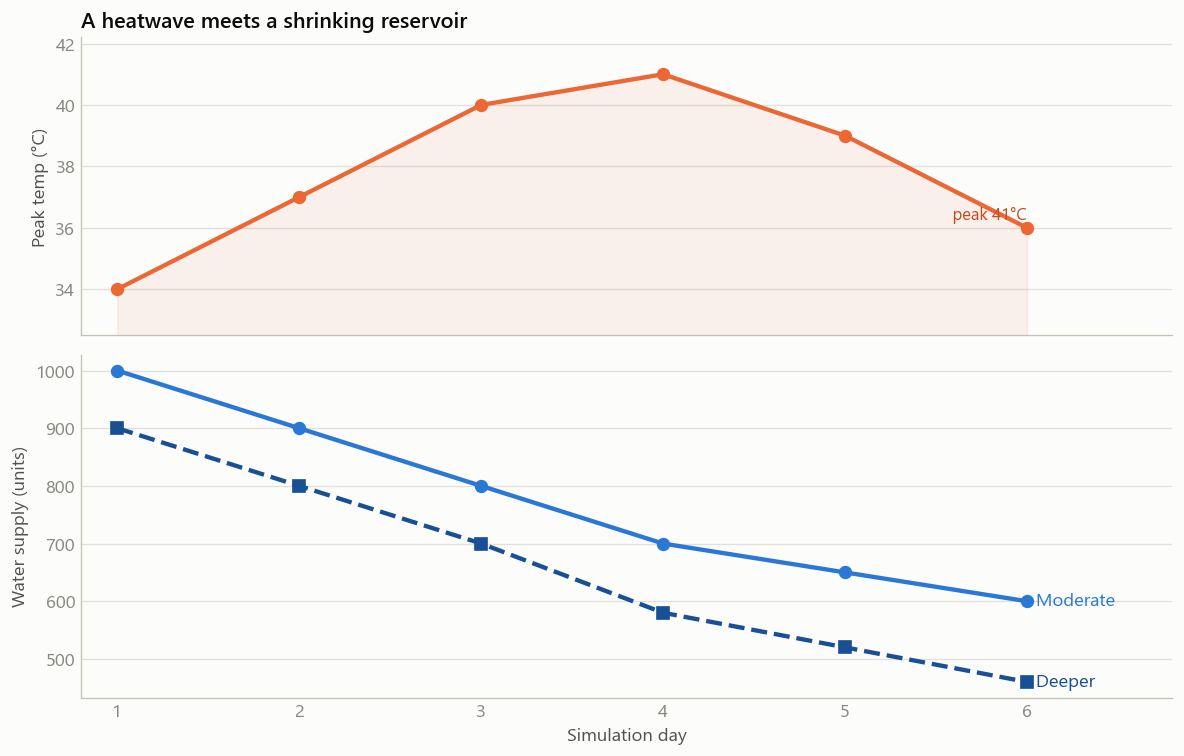

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.6), sharex=True,
                                height_ratios=[1, 1.15])

# Panel A - the heatwave (same profile in every condition)
temp = outcomes.groupby('day')['peak_temp_c'].mean().reindex(DAYS)
ax1.fill_between(DAYS, temp, temp.min() - 1.5, color='#eb6834', alpha=0.08)
ax1.plot(DAYS, temp, color='#eb6834', lw=2.6, marker='o', ms=7, zorder=3)
ax1.set_ylabel('Peak temp (°C)')
ax1.set_ylim(temp.min() - 1.5, temp.max() + 1.2)
ax1.set_title('A heatwave meets a shrinking reservoir', loc='left')
ax1.text(DAYS[-1], temp.iloc[-1] + 0.15, ' peak 41°C', color='#c24a1e',
         va='bottom', ha='right', fontsize=10)

# Panel B - supply. no_cascade and cascade share one schedule; deeper is lower.
sup = outcomes.groupby(['condition', 'day'])['supply'].first().unstack()
ax2.plot(DAYS, sup.loc['no_cascade'], color='#2a78d6', lw=2.6, marker='o', ms=7)
ax2.plot(DAYS, sup.loc['deeper_cascade'], color='#184f95', lw=2.6, marker='s',
         ms=7, ls='--')
ax2.text(6.02, sup.loc['no_cascade', 6], ' Moderate', color='#2a78d6', va='center')
ax2.text(6.02, sup.loc['deeper_cascade', 6], ' Deeper', color='#184f95', va='center')
ax2.set_ylabel('Water supply (units)'); ax2.set_xlabel('Simulation day')
ax2.set_xticks(DAYS); ax2.set_xlim(0.8, 6.8)

clean(ax1); clean(ax2)
fig.suptitle('')
plt.tight_layout(); plt.show()

## 3. Who actually gets water — satisfaction over time

**Satisfaction = allocated ÷ requested.** A value of 1.0 (dotted line) means a sector
got everything it asked for; lower means it was rationed. Reading the three panels
left to right shows how the split holds under deepening scarcity. Watch which lines
stay pinned near the top (protected sectors) and which slide as the reservoir drains.


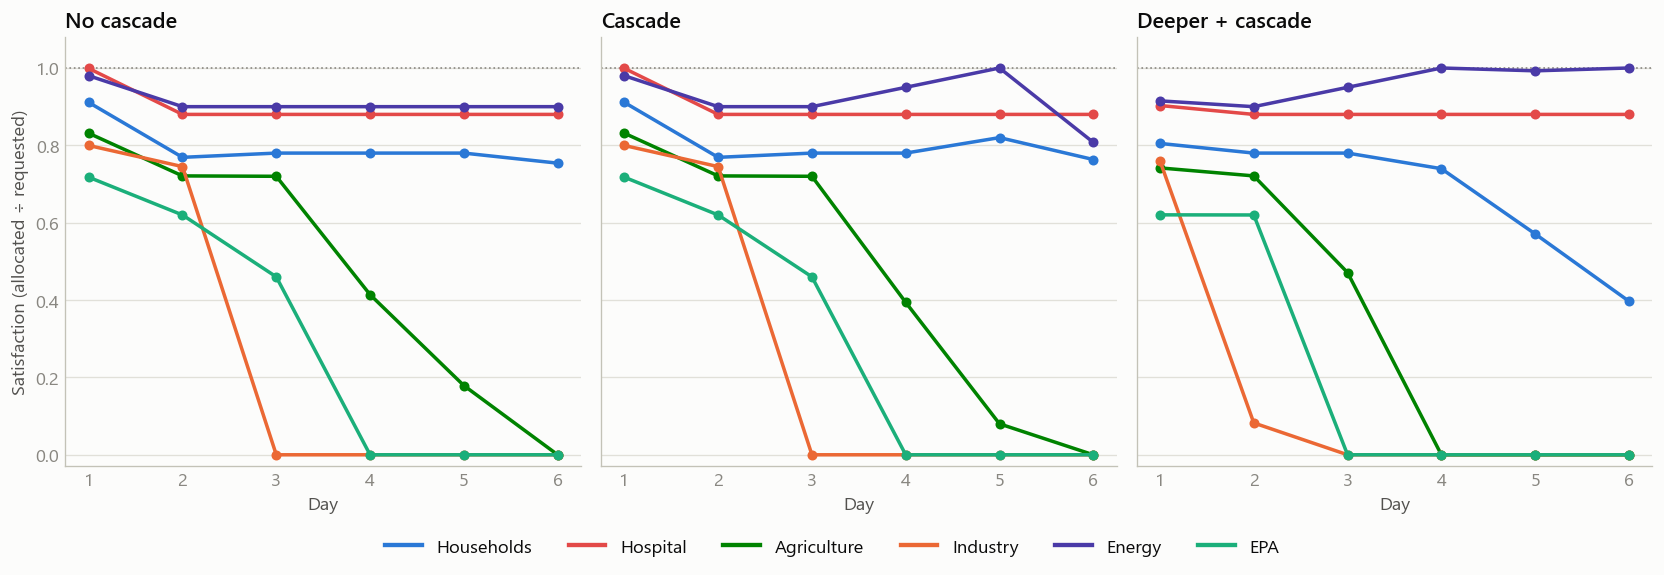

In [6]:
sat = (outcomes.groupby(['condition', 'name', 'day'])['satisfaction']
       .mean().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.7), sharey=True)
for ax, cond in zip(axes, COND_ORDER):
    sub = sat[sat.condition == cond]
    for name in STK_ORDER:
        s = sub[sub.name == name].set_index('day')['satisfaction'].reindex(DAYS)
        ax.plot(DAYS, s, color=STK_COLOR[name], lw=2.1, marker='o', ms=5, zorder=3)
    ax.axhline(1.0, color=MUTED, lw=1, ls=':', zorder=1)
    ax.set_title(COND_LABEL[cond], loc='left')
    ax.set_xlabel('Day'); ax.set_xticks(DAYS)
    ax.set_ylim(-0.03, 1.08)
    clean(ax)
axes[0].set_ylabel('Satisfaction (allocated ÷ requested)')

handles = [Line2D([0], [0], color=STK_COLOR[n], lw=2.6) for n in STK_ORDER]
fig.legend(handles, [STK_SHORT[n] for n in STK_ORDER], loc='lower center',
           ncol=6, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

## 4. The rationing gap — asked for vs received

Under the harshest condition (`deeper_cascade`), how far does each sector's
**allocation** fall short of its **request**? Each dot pair is a *dumbbell*: the grey
dot is the average daily demand, the coloured dot is what the sector received, and
the bar between them is the unmet gap (labelled in units). This is the clearest single
picture of who absorbs the scarcity.


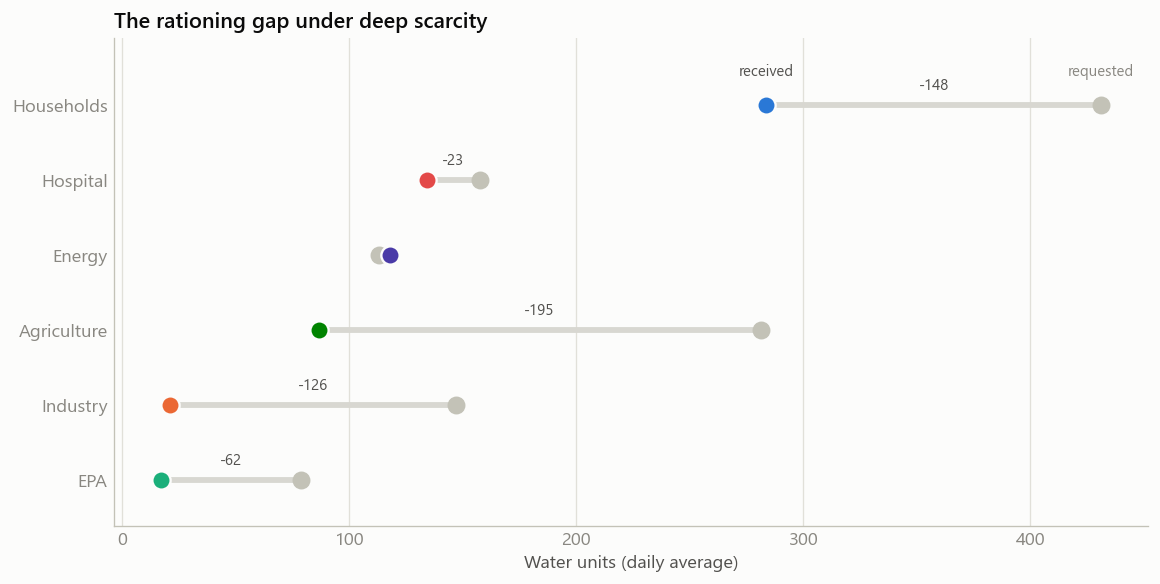

In [7]:
g = (outcomes[outcomes.condition == 'deeper_cascade']
     .groupby('name')[['requested', 'allocated']].mean())
g['gap'] = g['requested'] - g['allocated']
g = g.reindex(STK_ORDER).sort_values('allocated')

fig, ax = plt.subplots(figsize=(9.8, 5))
for i, (name, r) in enumerate(g.iterrows()):
    ax.plot([r.allocated, r.requested], [i, i], color=GAPLINE, lw=3.5, zorder=1)
    ax.scatter(r.requested, i, s=95, color='#c3c2b7', zorder=2)
    ax.scatter(r.allocated, i, s=120, color=STK_COLOR[name], zorder=3,
               edgecolor=SURFACE, linewidth=1.4)
    if r.gap > 1:
        ax.text((r.allocated + r.requested) / 2, i + 0.16, f'-{r.gap:.0f}',
                color=INK2, ha='center', va='bottom', fontsize=9)

# label the two dot types on the top row
top = len(g) - 1
ax.text(g.iloc[-1].allocated, top + 0.34, 'received', color=INK2,
        ha='center', va='bottom', fontsize=9)
ax.text(g.iloc[-1].requested, top + 0.34, 'requested', color=MUTED,
        ha='center', va='bottom', fontsize=9)

ax.set_yticks(range(len(g)))
ax.set_yticklabels([STK_SHORT[n] for n in g.index])
ax.set_xlabel('Water units (daily average)')
ax.set_title('The rationing gap under deep scarcity', loc='left')
ax.set_ylim(-0.6, len(g) - 0.1)
clean(ax, axis='x'); plt.tight_layout(); plt.show()

## 5. Sliding toward crisis — service zones by day

Each sector sits in one of three zones: **comfortable** (above its comfortable
threshold), **middle** (in the trading band), or **critical** (below the hard failure
floor). The stacked bars count how many of the six sectors occupy each zone on each
day, averaged over seeds. A healthy system is mostly green; a failing one turns red.
The contrast between the left and right panels is the cost of deeper scarcity.


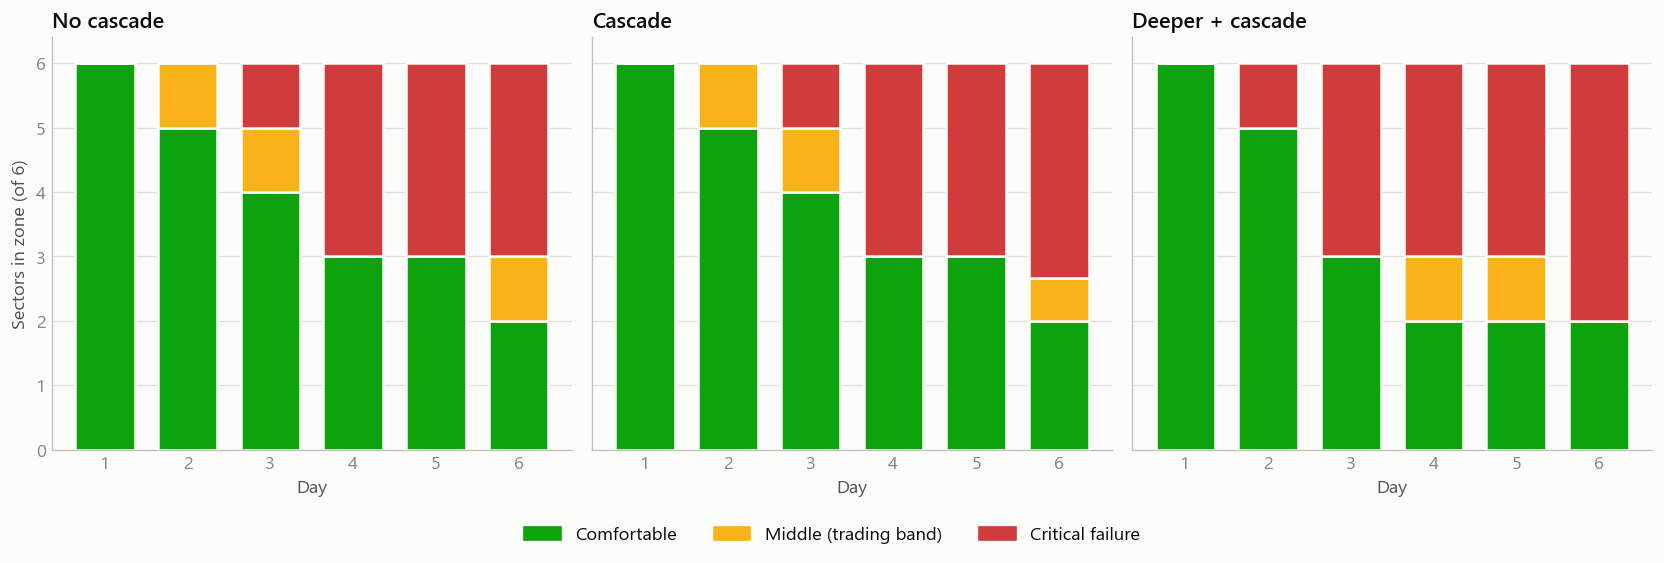

In [8]:
# Count sectors per zone for each run-day, filling absent zones with 0 so every
# run-day sums to exactly 6, then average those counts across the three seeds.
zc = (zones.groupby(['condition', 'day', 'seed', 'zone']).size()
      .unstack('zone').reindex(columns=ZONE_ORDER).fillna(0)
      .groupby(['condition', 'day']).mean())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
for ax, cond in zip(axes, COND_ORDER):
    piv = zc.loc[cond].reindex(index=DAYS).fillna(0)[ZONE_ORDER]
    bottom = np.zeros(len(DAYS))
    for zone in ZONE_ORDER:
        ax.bar(DAYS, piv[zone], bottom=bottom, color=ZONE_COLOR[zone],
               width=0.72, edgecolor=SURFACE, linewidth=1.5, zorder=3)
        bottom += piv[zone].values
    ax.set_title(COND_LABEL[cond], loc='left')
    ax.set_xlabel('Day'); ax.set_xticks(DAYS)
    ax.set_ylim(0, 6.4)
    clean(ax)
axes[0].set_ylabel('Sectors in zone (of 6)')

handles = [mpl.patches.Patch(color=ZONE_COLOR[z]) for z in ZONE_ORDER]
fig.legend(handles, ['Comfortable', 'Middle (trading band)', 'Critical failure'],
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

## 6. How agents negotiate — the move mix

Every negotiation move is one of three kinds: **propose trade** and **accept** are
cooperative; **object** is self-protective refusal. These 100 %-stacked bars show the
behavioural mix in each condition. The question the experiment poses: do *real*
cascade consequences (middle and bottom bars) shift agents away from objection and
toward cooperation, compared with scarcity alone (top bar)?


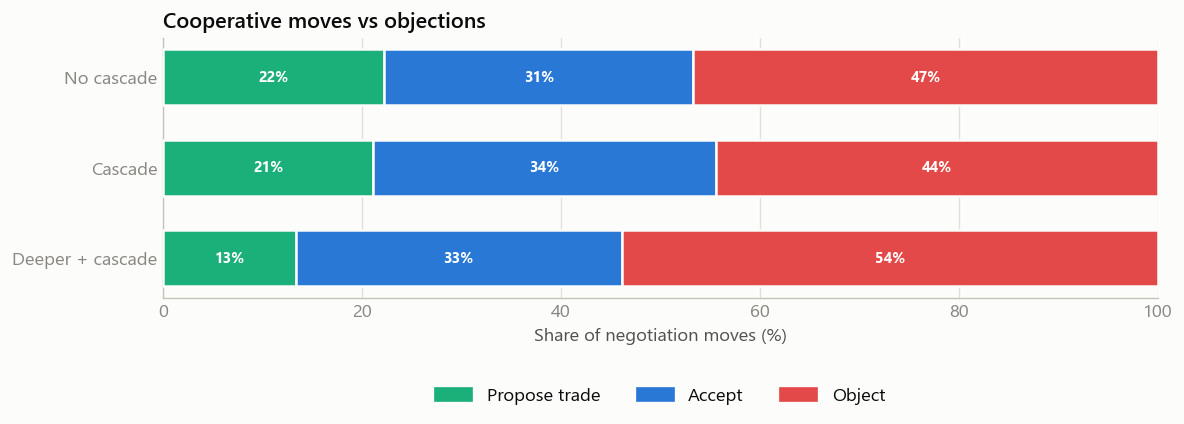

In [9]:
mv = decisions[decisions.event_type == 'move']
order = ['propose_trade', 'accept', 'object']
lbl = {'propose_trade': 'Propose trade', 'accept': 'Accept', 'object': 'Object'}
col = {'propose_trade': '#1baf7a', 'accept': '#2a78d6', 'object': '#e34948'}

comp = (mv.groupby(['condition', 'move_type']).size().unstack(fill_value=0)
        .reindex(index=COND_ORDER, columns=order).fillna(0))
pct = comp.div(comp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 3.9))
y = np.arange(len(COND_ORDER))
left = np.zeros(len(COND_ORDER))
for m in order:
    ax.barh(y, pct[m], left=left, color=col[m], height=0.62,
            edgecolor=SURFACE, linewidth=1.5, zorder=3)
    for i, v in enumerate(pct[m]):
        if v > 6:
            ax.text(left[i] + v / 2, i, f'{v:.0f}%', color='white',
                    ha='center', va='center', fontsize=9, fontweight='bold')
    left += pct[m].values

ax.set_yticks(y); ax.set_yticklabels([COND_LABEL[c] for c in COND_ORDER])
ax.set_xlabel('Share of negotiation moves (%)'); ax.set_xlim(0, 100)
ax.set_title('Cooperative moves vs objections', loc='left')
handles = [mpl.patches.Patch(color=col[m]) for m in order]
ax.legend(handles, [lbl[m] for m in order], ncol=3, loc='upper center',
          bbox_to_anchor=(0.5, -0.28))
clean(ax, axis='x'); ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 7. The Authority's politics — priority weights drift

After each day, the Authority updates every sector's **priority weight** — rewarding
cooperation and penalising strategic inflation (objecting while already comfortable).
Higher weight means stronger claim on tomorrow's water. These trajectories reveal the
emergent political economy: which sectors *earn* standing over the week and which
lose it. Sectors starting high (Hospital, Households) are the safety-critical ones.


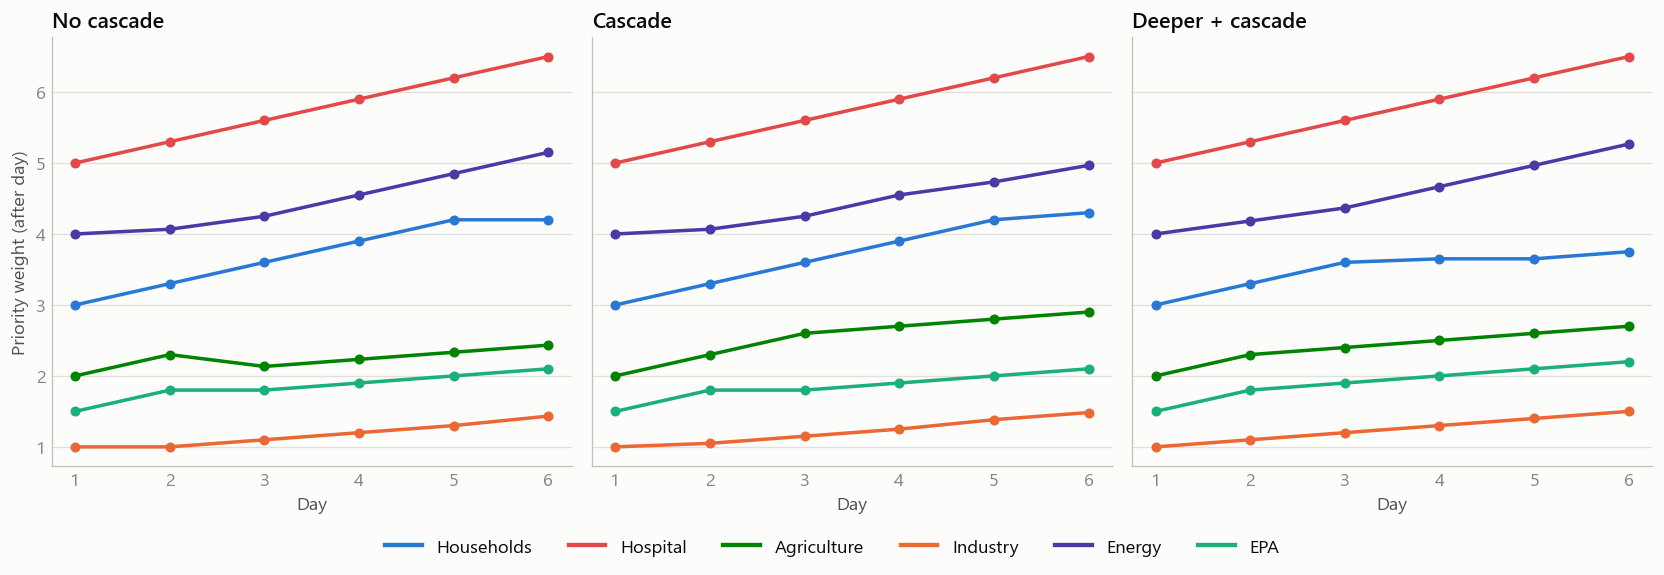

In [10]:
wt = (weights.groupby(['condition', 'name', 'day'])['weight_after']
      .mean().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.7), sharey=True)
for ax, cond in zip(axes, COND_ORDER):
    sub = wt[wt.condition == cond]
    for name in STK_ORDER:
        s = sub[sub.name == name].set_index('day')['weight_after'].reindex(DAYS)
        ax.plot(DAYS, s, color=STK_COLOR[name], lw=2.1, marker='o', ms=5, zorder=3)
    ax.set_title(COND_LABEL[cond], loc='left')
    ax.set_xlabel('Day'); ax.set_xticks(DAYS)
    clean(ax)
axes[0].set_ylabel('Priority weight (after day)')

handles = [Line2D([0], [0], color=STK_COLOR[n], lw=2.6) for n in STK_ORDER]
fig.legend(handles, [STK_SHORT[n] for n in STK_ORDER], loc='lower center',
           ncol=6, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

## 8. Headline outcomes — the three conditions compared

Four run-level metrics, averaged over the three seeds (error bars = ±1 SD). These are
computed only from the deterministic ledger, never from what an agent *says*:

- **Cooperation rate** — share of moves that were cooperative *(higher is better)*.
- **Critical failures** — total sector-days below the hard floor *(lower is better)*.
- **Rawlsian welfare** — satisfaction of the *worst-off* sector *(higher is better)*.
- **Gini inequality** — spread of satisfaction across sectors *(lower = fairer)*.


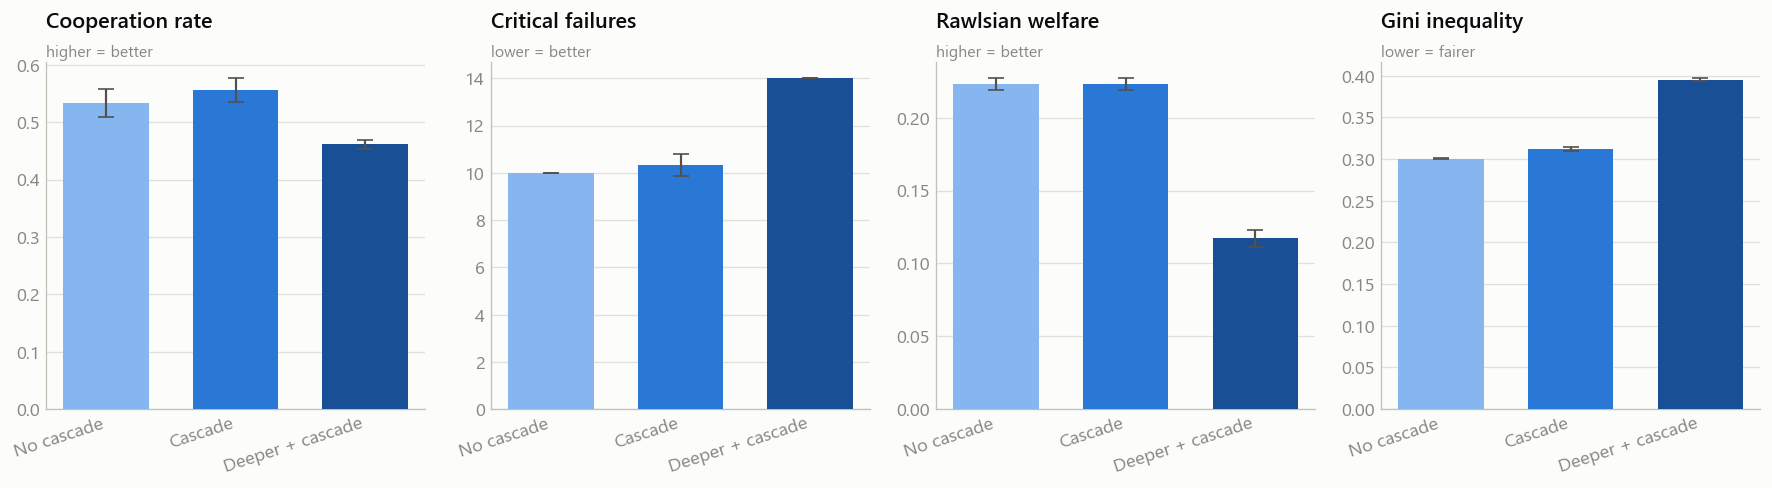

In [11]:
def gini(x):
    x = np.sort(np.asarray(x, float)); n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)

# Per run-day fairness / welfare, then per-run summary across seeds
day_df = (outcomes.groupby(['run_id', 'condition', 'seed', 'day'])
          .agg(gini=('satisfaction', lambda s: gini(s.values)),
               min_sat=('satisfaction', 'min'),
               crit=('critical_failure', 'sum')).reset_index())

rows = []
for (rid, cond, seed), grp in day_df.groupby(['run_id', 'condition', 'seed']):
    mvr = decisions[(decisions.run_id == rid) & (decisions.event_type == 'move')]
    n = len(mvr)
    coop = int(mvr.move_type.isin(['accept', 'propose_trade']).sum())
    rows.append({'condition': cond,
                 'Cooperation rate': coop / n if n else np.nan,
                 'Critical failures': grp.crit.sum(),
                 'Rawlsian welfare': grp.min_sat.mean(),
                 'Gini inequality': grp.gini.mean()})
summ = pd.DataFrame(rows)

metrics = ['Cooperation rate', 'Critical failures', 'Rawlsian welfare', 'Gini inequality']
hint = ['higher = better', 'lower = better', 'higher = better', 'lower = fairer']
mean = summ.groupby('condition')[metrics].mean().reindex(COND_ORDER)
std = summ.groupby('condition')[metrics].std(ddof=0).reindex(COND_ORDER)

fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))
x = np.arange(len(COND_ORDER))
bar_colors = [COND_COLOR[c] for c in COND_ORDER]
for ax, metric, h in zip(axes, metrics, hint):
    ax.bar(x, mean[metric], yerr=std[metric], capsize=5, color=bar_colors,
           width=0.66, zorder=3, error_kw={'ecolor': INK2, 'elinewidth': 1.3})
    ax.set_xticks(x)
    ax.set_xticklabels([COND_LABEL[c] for c in COND_ORDER], rotation=18, ha='right')
    ax.set_title(f'{metric}\n', loc='left')
    ax.text(0, 1.015, h, transform=ax.transAxes, color=MUTED, fontsize=9.5)
    clean(ax)
plt.tight_layout(); plt.show()

## 9. What moves with what — correlation heatmap

Pooling all sector-days, this heatmap shows how the key quantities move together.
Blue = they rise and fall in opposite directions; red = they move together; grey ≈ no
relationship. It is a fast way to confirm the mechanics — e.g. how **deficit** and
**shortfall** track the drop in **satisfaction**, and how much **supply** and
**temperature** ultimately steer the daily outcome.


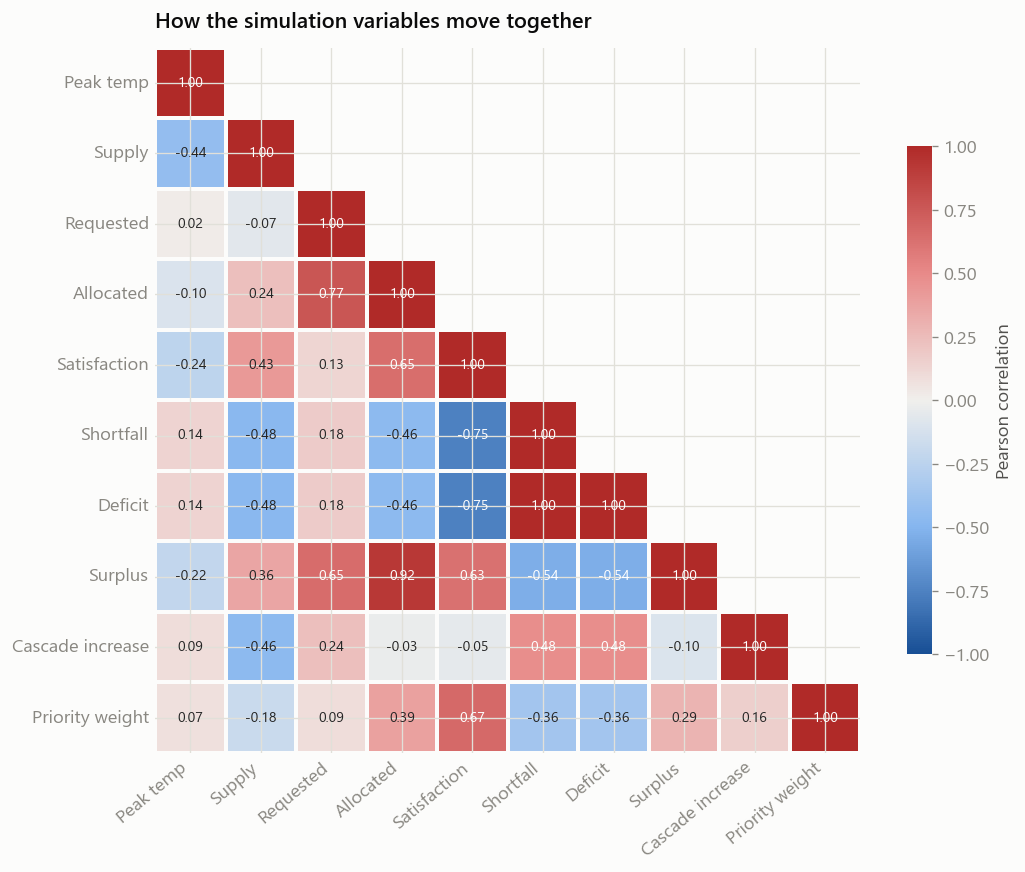

In [12]:
m = (outcomes
     .merge(zones[['day', 'stakeholder_id', 'condition', 'seed',
                   'surplus_above_critical', 'deficit_below_comfortable']],
            on=['day', 'stakeholder_id', 'condition', 'seed'], how='left')
     .merge(weights[['day', 'stakeholder_id', 'condition', 'seed', 'weight_after']],
            on=['day', 'stakeholder_id', 'condition', 'seed'], how='left'))

cols = ['peak_temp_c', 'supply', 'requested', 'allocated', 'satisfaction',
        'shortfall_comfortable', 'deficit_below_comfortable',
        'surplus_above_critical', 'cascade_increase', 'weight_after']
nice = ['Peak temp', 'Supply', 'Requested', 'Allocated', 'Satisfaction',
        'Shortfall', 'Deficit', 'Surplus', 'Cascade increase', 'Priority weight']
corr = m[cols].corr()
corr.index = corr.columns = nice
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9.2, 7.4))
sns.heatmap(corr, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8.5}, square=True,
            linewidths=1.4, linecolor=SURFACE,
            cbar_kws={'shrink': 0.72, 'label': 'Pearson correlation'}, ax=ax)
ax.set_title('How the simulation variables move together', loc='left', pad=12)
ax.tick_params(length=0)
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout(); plt.show()

## 10. Reliability of service — satisfaction distribution by sector

The final view pools every sector-day across all runs to show not just the *average*
service a sector receives, but its **spread**. A tall box means volatile, unpredictable
supply; a compact box near 1.0 means dependable service. The order on the x-axis is
the same fixed sector order used throughout. This exposes the structural winners and
losers of the allocation rules — the human core of the fairness question.


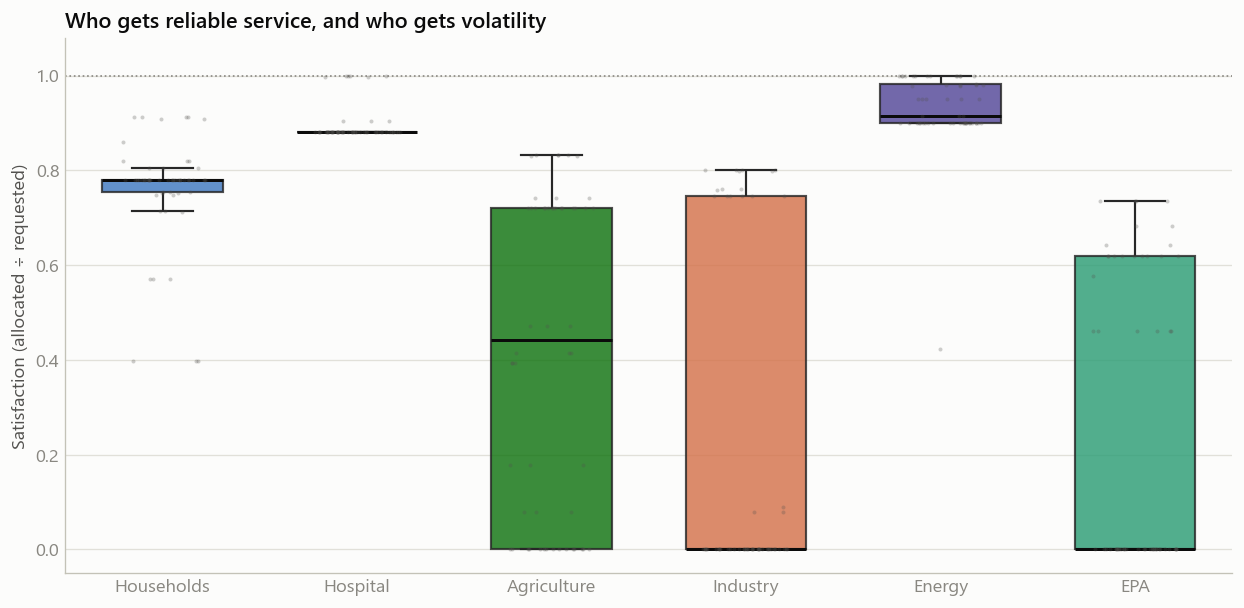

In [13]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
pal = {n: STK_COLOR[n] for n in STK_ORDER}

sns.boxplot(data=outcomes, x='name', y='satisfaction', order=STK_ORDER,
            hue='name', palette=pal, legend=False, width=0.62,
            fliersize=0, linewidth=1.3, ax=ax,
            boxprops={'alpha': 0.82}, medianprops={'color': INK, 'linewidth': 1.8})
sns.stripplot(data=outcomes, x='name', y='satisfaction', order=STK_ORDER,
              color=INK2, size=2.4, alpha=0.28, jitter=0.22, ax=ax)

ax.axhline(1.0, color=MUTED, lw=1, ls=':', zorder=1)
ax.set_xticklabels([STK_SHORT[n] for n in STK_ORDER])
ax.set_xlabel(''); ax.set_ylabel('Satisfaction (allocated ÷ requested)')
ax.set_ylim(-0.05, 1.08)
ax.set_title('Who gets reliable service, and who gets volatility', loc='left')
clean(ax); plt.tight_layout(); plt.show()

## 11. Simple views — one chart, one message

The charts above pack a lot in. These four are deliberately plain: **one plot, one
takeaway each**, for a quick read or a slide.


**Who gets served?** Average satisfaction per sector across every run. The gap
between the top and bottom bars is the whole fairness story in one picture.


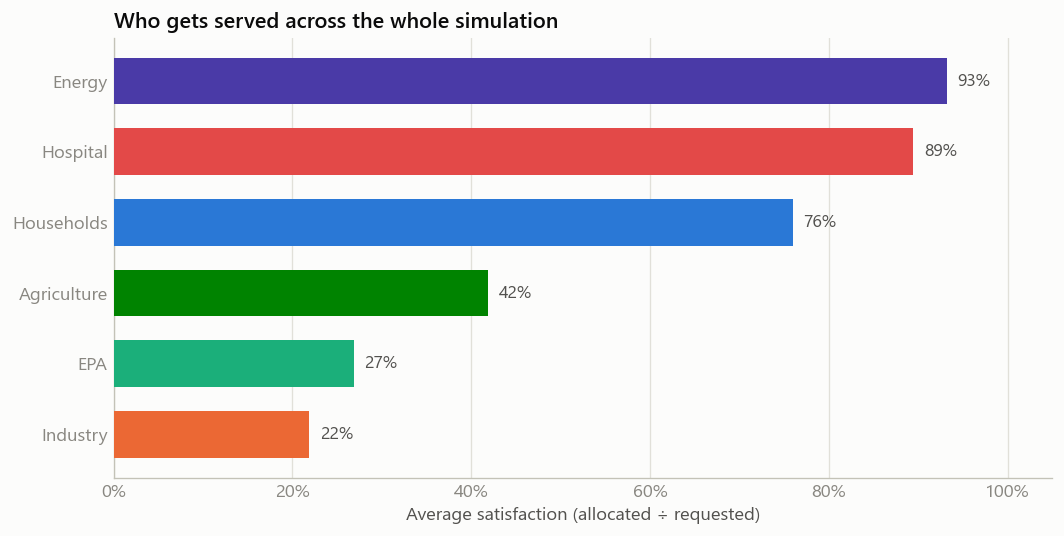

In [14]:
avg = (outcomes.groupby('name')['satisfaction'].mean()
       .reindex(STK_ORDER).sort_values())
labels = [STK_SHORT[n] for n in avg.index]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(labels, avg.values, color=[STK_COLOR[n] for n in avg.index],
        height=0.66, zorder=3)
for i, v in enumerate(avg.values):
    ax.text(v + 0.012, i, f'{v:.0%}', va='center', color=INK2, fontsize=10.5)
ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_xlabel('Average satisfaction (allocated ÷ requested)')
ax.set_title('Who gets served across the whole simulation', loc='left')
clean(ax, axis='x'); plt.tight_layout(); plt.show()

**Does it get worse over the week?** Average satisfaction across all six sectors,
one line per condition. All three slide downward; the deeper-scarcity line sits lowest.


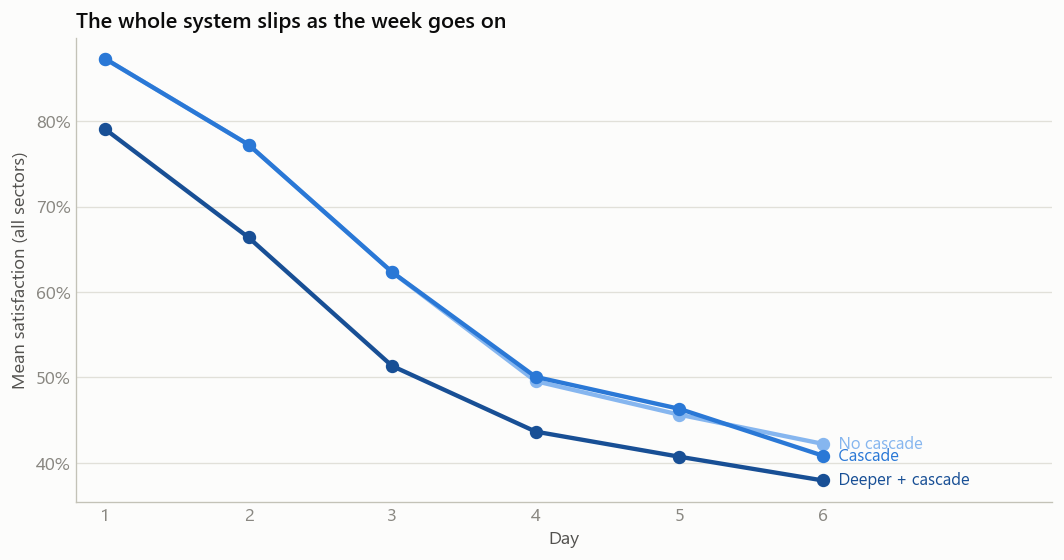

In [15]:
ms = (outcomes.groupby(['condition', 'day'])['satisfaction'].mean()
      .unstack('condition').reindex(DAYS))

fig, ax = plt.subplots(figsize=(9, 4.8))
for cond in COND_ORDER:
    ax.plot(DAYS, ms[cond], color=COND_COLOR[cond], lw=2.6, marker='o', ms=7)
    ax.text(6.08, ms[cond].iloc[-1], f' {COND_LABEL[cond]}',
            color=COND_COLOR[cond], va='center', fontsize=10)
ax.set_xticks(DAYS); ax.set_xlim(0.8, 7.6)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_ylabel('Mean satisfaction (all sectors)'); ax.set_xlabel('Day')
ax.set_title('The whole system slips as the week goes on', loc='left')
clean(ax); plt.tight_layout(); plt.show()

**How much does it break?** Total critical failures (sector-days below the hard
floor), summed over each condition's three runs. Deeper scarcity roughly doubles them.


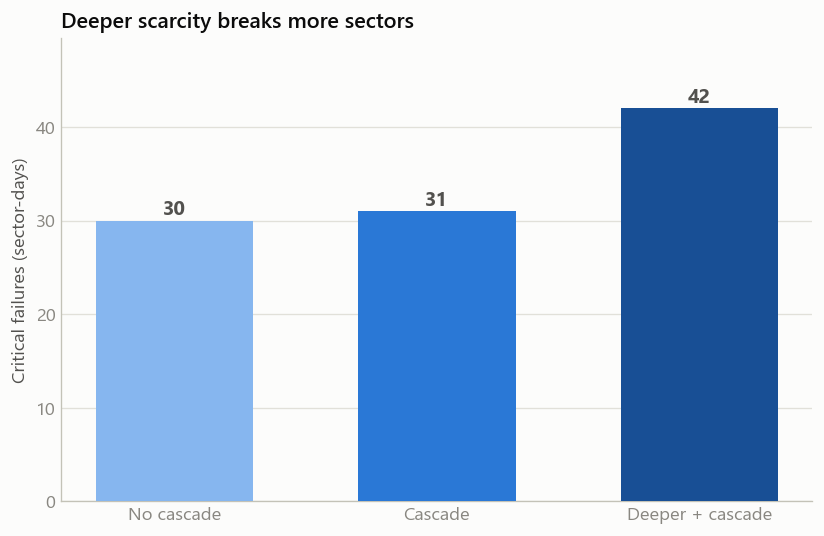

In [16]:
cf = outcomes.groupby('condition')['critical_failure'].sum().reindex(COND_ORDER)

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.bar([COND_LABEL[c] for c in COND_ORDER], cf.values,
       color=[COND_COLOR[c] for c in COND_ORDER], width=0.6, zorder=3)
for i, v in enumerate(cf.values):
    ax.text(i, v + 0.6, int(v), ha='center', color=INK2, fontsize=12, fontweight='bold')
ax.set_ylabel('Critical failures (sector-days)')
ax.set_ylim(0, cf.max() * 1.18)
ax.set_title('Deeper scarcity breaks more sectors', loc='left')
clean(ax); plt.tight_layout(); plt.show()

**Do agents cooperate more or less?** Share of negotiation moves that were
cooperative (trades + accepts). Cooperation is *lowest* exactly when scarcity is deepest.


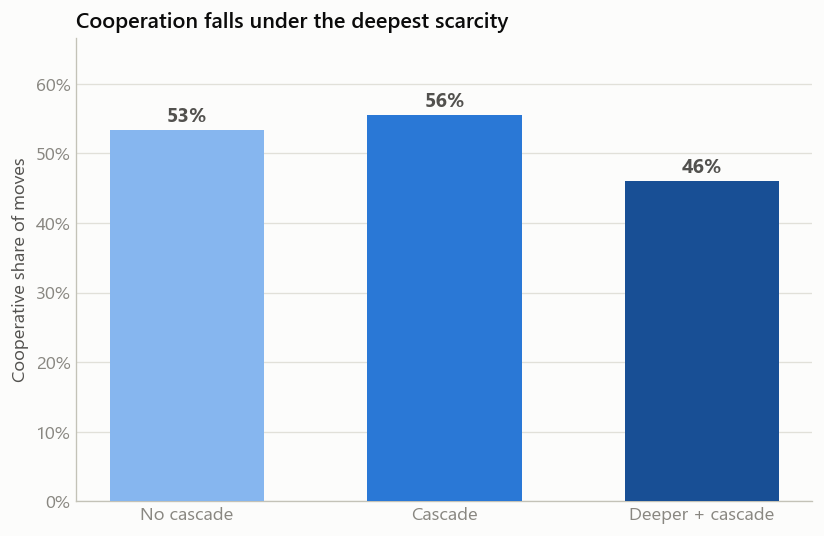

In [17]:
mv2 = decisions[decisions.event_type == 'move']
cr = (mv2.assign(coop=mv2.move_type.isin(['accept', 'propose_trade']))
      .groupby('condition')['coop'].mean().reindex(COND_ORDER))

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.bar([COND_LABEL[c] for c in COND_ORDER], cr.values,
       color=[COND_COLOR[c] for c in COND_ORDER], width=0.6, zorder=3)
for i, v in enumerate(cr.values):
    ax.text(i, v + 0.012, f'{v:.0%}', ha='center', color=INK2,
            fontsize=12, fontweight='bold')
ax.set_ylabel('Cooperative share of moves')
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_ylim(0, cr.max() * 1.2)
ax.set_title('Cooperation falls under the deepest scarcity', loc='left')
clean(ax); plt.tight_layout(); plt.show()

## 12. Reference tables

Three compact, styled summaries — coloured in-cell bars make the magnitudes readable
at a glance. Each is also written to `VISUAL/tables/` as **CSV** (raw numbers) and
**HTML** (styled), so they can be dropped into a report or slide later.


In [18]:
from pathlib import Path as _P
_P('tables').mkdir(exist_ok=True)

# Light bar tints keep the cell text readable
BLUE, GREEN, RED, ORANGE = '#bcd6f5', '#a9dcb8', '#f3b0af', '#f6c39b'

TBL_STYLES = [
    {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '13.5px'),
        ('font-weight', '600'), ('color', INK), ('text-align', 'left'),
        ('padding', '8px 2px')]},
    {'selector': 'th.col_heading', 'props': [('background-color', '#eef1f4'),
        ('color', INK2), ('font-weight', '600'), ('text-align', 'center'),
        ('padding', '7px 12px'), ('border-bottom', f'2px solid {AXIS}')]},
    {'selector': 'th.row_heading', 'props': [('background-color', '#f7f7f5'),
        ('color', INK), ('font-weight', '600'), ('text-align', 'left'),
        ('padding', '7px 12px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '7px 12px'),
        ('color', INK), ('border-bottom', f'1px solid {GRID}')]},
    {'selector': '', 'props': [('border-collapse', 'collapse'),
        ('font-family', 'Segoe UI, sans-serif'), ('font-size', '12.5px')]},
]

def save_table(styler, df, stem):
    "Persist raw CSV + styled HTML for reuse, then return the styler to display."
    df.to_csv(f'tables/{stem}.csv')
    styler.to_html(f'tables/{stem}.html')
    return styler

print('Table styling ready — files will be written to VISUAL/tables/')

Table styling ready — files will be written to VISUAL/tables/


**Table 1 — Sector scorecard.** What each sector asks for, what it receives, and
how often it lands in the comfortable vs critical zone. Blue = demand & supply,
green = good service, red = time spent in crisis.


In [19]:
sec = (outcomes.groupby('name')
       .agg(Requested=('requested', 'mean'),
            Received=('allocated', 'mean'),
            Satisfaction=('satisfaction', 'mean')).reindex(STK_ORDER))
zt = zones.assign(comf=zones.zone.eq('comfortable'), crit=zones.zone.eq('critical'))
zpct = zt.groupby('name')[['comf', 'crit']].mean() * 100
sec['Comfortable %'] = zpct['comf']
sec['Critical %'] = zpct['crit']
sec.index = [STK_SHORT[n] for n in sec.index]
sec.index.name = 'Sector'

vmax_units = sec[['Requested', 'Received']].values.max()
sty = (sec.style
       .format({'Requested': '{:.0f}', 'Received': '{:.0f}',
                'Satisfaction': '{:.0%}', 'Comfortable %': '{:.0f}%',
                'Critical %': '{:.0f}%'})
       .bar(subset=['Requested', 'Received'], color=BLUE, vmin=0, vmax=vmax_units, align='left')
       .bar(subset=['Satisfaction'], color=GREEN, vmin=0, vmax=1, align='left')
       .bar(subset=['Comfortable %'], color=GREEN, vmin=0, vmax=100, align='left')
       .bar(subset=['Critical %'], color=RED, vmin=0, vmax=100, align='left')
       .set_caption('Table 1 · Sector scorecard (averaged over all runs and days)')
       .set_table_styles(TBL_STYLES))
save_table(sty, sec, 'sector_scorecard')

,Requested,Received,Satisfaction,Comfortable %,Critical %
Sector,,,,,
Households,431,321,76%,74%,6%
Hospital,158,141,89%,100%,0%
Agriculture,282,112,42%,44%,56%
Industry,144,33,22%,17%,72%
Energy,112,107,93%,98%,2%
EPA,78,22,27%,33%,56%


**Table 2 — Condition comparison.** The four headline outcomes plus mean
satisfaction, averaged across seeds. Green columns are "higher is better"; red columns
are "lower is better".


In [20]:
cond_tbl = summ.groupby('condition').mean(numeric_only=True).reindex(COND_ORDER)
cond_tbl['Mean satisfaction'] = (outcomes.groupby('condition')['satisfaction']
                                 .mean().reindex(COND_ORDER))
cond_tbl = cond_tbl[['Mean satisfaction', 'Rawlsian welfare', 'Cooperation rate',
                     'Gini inequality', 'Critical failures']]
cond_tbl.index = [COND_LABEL[c] for c in cond_tbl.index]
cond_tbl.index.name = 'Condition'

sty2 = (cond_tbl.style
        .format({'Mean satisfaction': '{:.0%}', 'Rawlsian welfare': '{:.0%}',
                 'Cooperation rate': '{:.0%}', 'Gini inequality': '{:.3f}',
                 'Critical failures': '{:.1f}'})
        .bar(subset=['Mean satisfaction', 'Rawlsian welfare', 'Cooperation rate'],
             color=GREEN, vmin=0, vmax=1, align='left')
        .bar(subset=['Gini inequality'], color=RED, vmin=0, vmax=0.5, align='left')
        .bar(subset=['Critical failures'], color=RED, vmin=0,
             vmax=float(cond_tbl['Critical failures'].max()), align='left')
        .set_caption('Table 2 · Outcomes by condition (mean over 3 seeds)')
        .set_table_styles(TBL_STYLES))
save_table(sty2, cond_tbl, 'condition_comparison')

,Mean satisfaction,Rawlsian welfare,Cooperation rate,Gini inequality,Critical failures
Condition,,,,,
No cascade,61%,22%,53%,0.301,10.0
Cascade,61%,22%,56%,0.312,10.3
Deeper + cascade,53%,12%,46%,0.395,14.0


**Table 3 — Daily system tracker.** Day by day: how hot it got, how much water
was available under each supply schedule, the average satisfaction, and how many
sectors were in critical failure. A one-row-per-day pulse of the whole run.


In [21]:
sup = outcomes.groupby(['condition', 'day'])['supply'].first().unstack('condition')
n_runs = zones.groupby('day')['run_id'].nunique()
crit_day = (zones[zones.zone.eq('critical')].groupby('day').size() / n_runs)

day_tbl = pd.DataFrame({
    'Peak temp °C': outcomes.groupby('day')['peak_temp_c'].mean(),
    'Supply · moderate': sup['no_cascade'],
    'Supply · deeper': sup['deeper_cascade'],
    'Mean satisfaction': outcomes.groupby('day')['satisfaction'].mean(),
    'Sectors in crisis': crit_day.reindex(DAYS).fillna(0),
}).reindex(DAYS)
day_tbl.index.name = 'Day'

sty3 = (day_tbl.style
        .format({'Peak temp °C': '{:.0f}', 'Supply · moderate': '{:.0f}',
                 'Supply · deeper': '{:.0f}', 'Mean satisfaction': '{:.0%}',
                 'Sectors in crisis': '{:.1f}'})
        .bar(subset=['Peak temp °C'], color=ORANGE, vmin=32, vmax=42, align='left')
        .bar(subset=['Supply · moderate', 'Supply · deeper'], color=BLUE,
             vmin=0, vmax=1000, align='left')
        .bar(subset=['Mean satisfaction'], color=GREEN, vmin=0, vmax=1, align='left')
        .bar(subset=['Sectors in crisis'], color=RED, vmin=0, vmax=6, align='left')
        .set_caption('Table 3 · Daily system tracker (averaged across all runs)')
        .set_table_styles(TBL_STYLES))
save_table(sty3, day_tbl, 'daily_tracker')

,Peak temp °C,Supply · moderate,Supply · deeper,Mean satisfaction,Sectors in crisis
Day,,,,,
1,34,1000,900,85%,0.0
2,37,900,800,74%,0.3
3,40,800,700,59%,1.7
4,41,700,580,48%,3.0
5,39,650,520,44%,3.0
6,36,600,460,40%,3.4


## Key takeaways

- **The stress is real and rising.** Heat peaks at 41 °C mid-week while supply falls
  ~40 %; the `deeper_cascade` schedule starts lower and ends lowest (chart 2).
- **Scarcity is not shared equally.** Safety-critical sectors (Hospital, Households)
  stay near full satisfaction while Agriculture, Industry and the EPA absorb the
  rationing gap (charts 3, 4, 10).
- **Deeper scarcity pushes more sectors below the failure floor** — the critical-zone
  band grows and Rawlsian welfare drops in the harshest condition (charts 5, 8).
- **Objection is the default move**, but cooperative trades and accepts still make up a
  meaningful share; the conditions reveal how cascade stakes shift that mix (chart 6).
- **The Authority's weights encode a politics of cooperation** — standing drifts over
  the week as behaviour is rewarded or penalised (chart 7).
- **The correlation structure confirms the mechanics** — deficit and shortfall track
  falling satisfaction, and supply/temperature steer the daily result (chart 9).


## 13. Objections vs cooperation, day by day

Chart 6 showed the *overall* move mix; here we trace how it **evolves across the
week**. Every negotiation move is either **cooperative** (`propose_trade` + `accept`)
or an **objection** (a self-protective refusal). Day 1 is opening requests only, so
moves begin on day 2.

We look at it three ways: the **daily flip** from cooperation to objection (13a), the
same story as a **share ribbon** (13b), and the **objection rate per condition** —
whether deeper scarcity makes agents dig in sooner (13c).

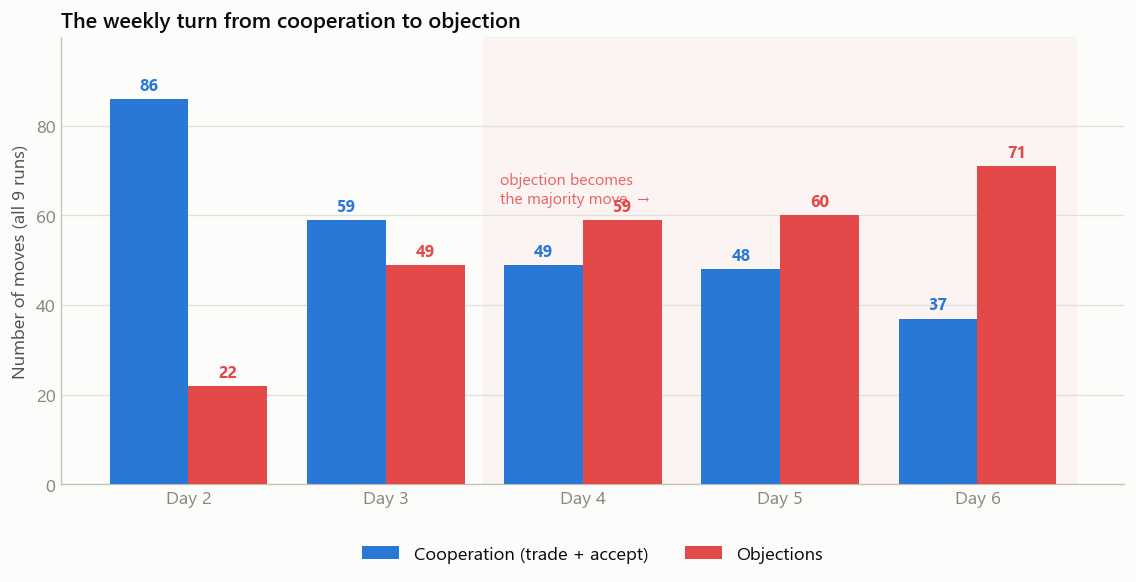

In [22]:
# --- Shared prep: classify every move as cooperative (trade/accept) or objection
mvd = decisions[decisions.event_type == 'move'].copy()
mvd['coop'] = mvd.move_type.isin(['propose_trade', 'accept'])
mvd['obj'] = mvd.move_type.eq('object')

COOP_C, OBJ_C = '#2a78d6', '#e34948'          # cooperation = blue, objection = red

# Pooled per-day counts (all nine runs together)
per_day = mvd.groupby('day').agg(Cooperation=('coop', 'sum'),
                                 Objections=('obj', 'sum'),
                                 Total=('move_type', 'size'))
per_day['Coop %'] = per_day.Cooperation / per_day.Total * 100
per_day['Obj %'] = per_day.Objections / per_day.Total * 100
MDAYS = list(per_day.index)                   # days that actually contain moves (2..6)

# === Chart 13a — daily counts: cooperation vs objection =======================
fig, ax = plt.subplots(figsize=(9.6, 5))
w = 0.4
x = np.arange(len(MDAYS))
b1 = ax.bar(x - w / 2, per_day.Cooperation, width=w, color=COOP_C,
            zorder=3, label='Cooperation (trade + accept)')
b2 = ax.bar(x + w / 2, per_day.Objections, width=w, color=OBJ_C,
            zorder=3, label='Objections')
ax.bar_label(b1, padding=3, color=COOP_C, fontsize=10, fontweight='bold')
ax.bar_label(b2, padding=3, color=OBJ_C, fontsize=10, fontweight='bold')

# mark the day cooperation is overtaken by objection
cross = next((d for d in MDAYS if per_day.loc[d, 'Obj %'] > 50), None)
if cross is not None:
    ci = MDAYS.index(cross)
    ax.axvspan(ci - 0.5, len(MDAYS) - 0.5, color=OBJ_C, alpha=0.04, zorder=0)
    ax.text(ci - 0.42, per_day.Objections.max() * 0.98,
            'objection becomes\nthe majority move  →', color=OBJ_C, alpha=0.85,
            fontsize=9.5, va='top', ha='left')

ax.set_xticks(x); ax.set_xticklabels([f'Day {d}' for d in MDAYS])
ax.set_ylabel('Number of moves (all 9 runs)')
ax.set_ylim(0, per_day[['Cooperation', 'Objections']].values.max() * 1.16)
ax.set_title('The weekly turn from cooperation to objection', loc='left')
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.1))
clean(ax); plt.tight_layout(); plt.show()

**13b — The same story as a share ribbon.** Each day's moves normalised to 100 %, so
the crossover is unmistakable: the blue cooperation band shrinks day by day while the
red objection band swells past the halfway line.

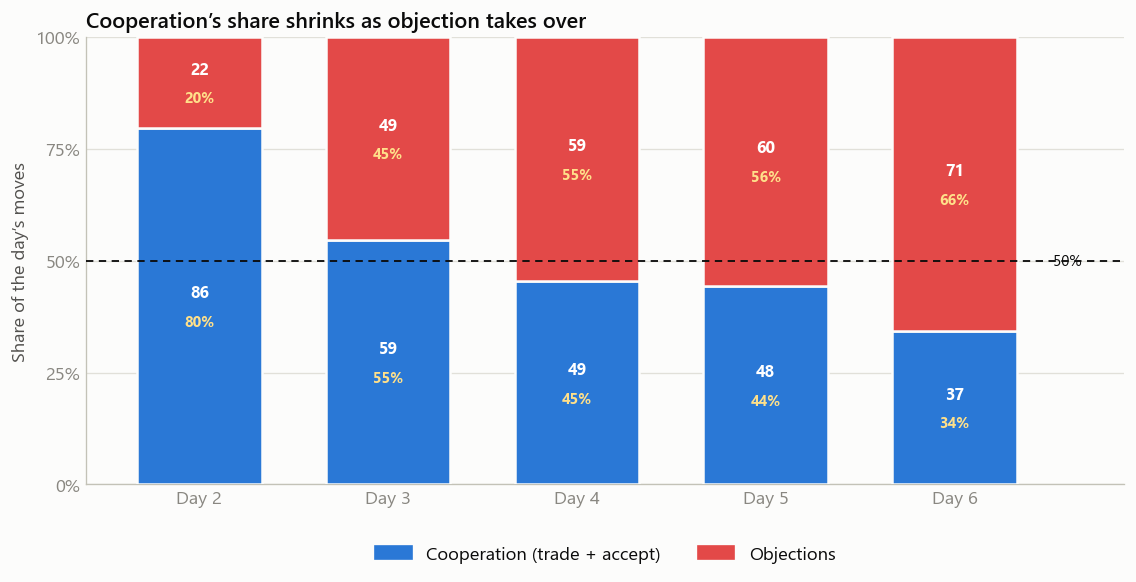

In [23]:
# === Chart 13b — 100%-stacked share ribbon, cooperation vs objection ==========
PCT_C = '#ffe08a'   # warm accent for the % labels, so they read apart from the counts

fig, ax = plt.subplots(figsize=(9.6, 5))
x = np.arange(len(MDAYS))
bw = 0.66

ax.bar(x, per_day['Coop %'], width=bw, color=COOP_C, zorder=3,
       edgecolor=SURFACE, linewidth=1.5)
ax.bar(x, per_day['Obj %'], bottom=per_day['Coop %'], width=bw, color=OBJ_C,
       zorder=3, edgecolor=SURFACE, linewidth=1.5)

# count (white) + share (amber) stacked inside each segment
for i, d in enumerate(MDAYS):
    c, o = per_day.loc[d, 'Coop %'], per_day.loc[d, 'Obj %']
    ax.text(i, c / 2 + 3, f"{int(per_day.loc[d, 'Cooperation'])}", ha='center',
            va='center', color='white', fontsize=10, fontweight='bold')
    ax.text(i, c / 2 - 3.5, f"{c:.0f}%", ha='center', va='center',
            color=PCT_C, fontsize=9, fontweight='bold')
    ax.text(i, c + o / 2 + 3, f"{int(per_day.loc[d, 'Objections'])}", ha='center',
            va='center', color='white', fontsize=10, fontweight='bold')
    ax.text(i, c + o / 2 - 3.5, f"{o:.0f}%", ha='center', va='center',
            color=PCT_C, fontsize=9, fontweight='bold')

ax.axhline(50, color=INK, lw=1.1, ls=(0, (4, 3)), zorder=4)
ax.text(len(MDAYS) - 0.5, 50, ' 50%', color=INK, va='center', ha='left', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'Day {d}' for d in MDAYS])
ax.set_ylim(0, 100); ax.set_yticks(range(0, 101, 25))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.set_ylabel('Share of the day’s moves')
ax.set_title('Cooperation’s share shrinks as objection takes over', loc='left')

handles = [mpl.patches.Patch(color=COOP_C), mpl.patches.Patch(color=OBJ_C)]
ax.legend(handles, ['Cooperation (trade + accept)', 'Objections'],
          loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.1))
clean(ax, axis='y'); ax.set_xlim(-0.6, len(MDAYS) - 0.1)
plt.tight_layout(); plt.show()

**13b split three ways — one ribbon per condition.** The same 100 %-stacked view, but
broken out by condition so the schedules can be compared side by side. Each column is
one day's 36 moves (3 seeds × ~12 moves); the white number is the move count, the
amber number is its share.

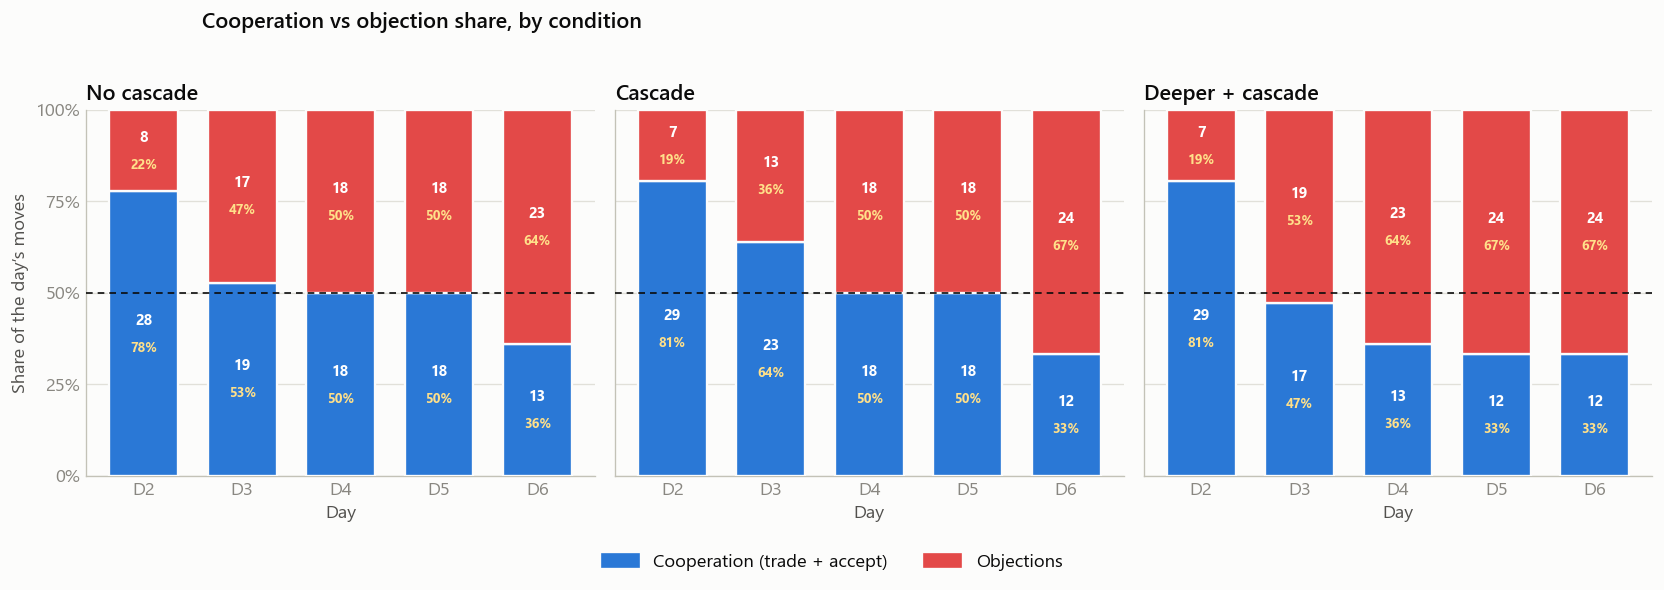

In [24]:
# === Chart 13b (per condition) — share ribbon split by condition ==============
# Counts per condition x day, then cooperation/objection shares within each day
cc = (mvd.groupby(['condition', 'day']).agg(Cooperation=('coop', 'sum'),
                                            Objections=('obj', 'sum'),
                                            Total=('move_type', 'size')))
cc['Coop %'] = cc.Cooperation / cc.Total * 100
cc['Obj %'] = cc.Objections / cc.Total * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4.7), sharey=True)
x = np.arange(len(MDAYS))
for ax, cond in zip(axes, COND_ORDER):
    sub = cc.loc[cond].reindex(MDAYS)
    ax.bar(x, sub['Coop %'], width=0.7, color=COOP_C, zorder=3,
           edgecolor=SURFACE, linewidth=1.4)
    ax.bar(x, sub['Obj %'], bottom=sub['Coop %'], width=0.7, color=OBJ_C, zorder=3,
           edgecolor=SURFACE, linewidth=1.4)
    for i, d in enumerate(MDAYS):
        c, o = sub.loc[d, 'Coop %'], sub.loc[d, 'Obj %']
        ax.text(i, c / 2 + 3.5, f"{int(sub.loc[d, 'Cooperation'])}", ha='center',
                va='center', color='white', fontsize=9, fontweight='bold')
        ax.text(i, c / 2 - 4, f"{c:.0f}%", ha='center', va='center',
                color=PCT_C, fontsize=8, fontweight='bold')
        ax.text(i, c + o / 2 + 3.5, f"{int(sub.loc[d, 'Objections'])}", ha='center',
                va='center', color='white', fontsize=9, fontweight='bold')
        ax.text(i, c + o / 2 - 4, f"{o:.0f}%", ha='center', va='center',
                color=PCT_C, fontsize=8, fontweight='bold')
    ax.axhline(50, color=INK, lw=1, ls=(0, (4, 3)), zorder=4)
    ax.set_title(COND_LABEL[cond], loc='left')
    ax.set_xticks(x); ax.set_xticklabels([f'D{d}' for d in MDAYS])
    ax.set_ylim(0, 100); ax.set_yticks(range(0, 101, 25))
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter())
    ax.set_xlabel('Day')
    clean(ax, axis='y')
axes[0].set_ylabel('Share of the day’s moves')

handles = [mpl.patches.Patch(color=COOP_C), mpl.patches.Patch(color=OBJ_C)]
fig.legend(handles, ['Cooperation (trade + accept)', 'Objections'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Cooperation vs objection share, by condition', x=0.125, ha='left',
             fontsize=13, fontweight='semibold')
plt.tight_layout(rect=[0, 0.04, 1, 0.96]); plt.show()

**13c — Does deeper scarcity tip sooner?** The objection rate for each condition,
day by day. All three climb, but the deeper-scarcity line crosses the 50 % line
earliest and plateaus highest.

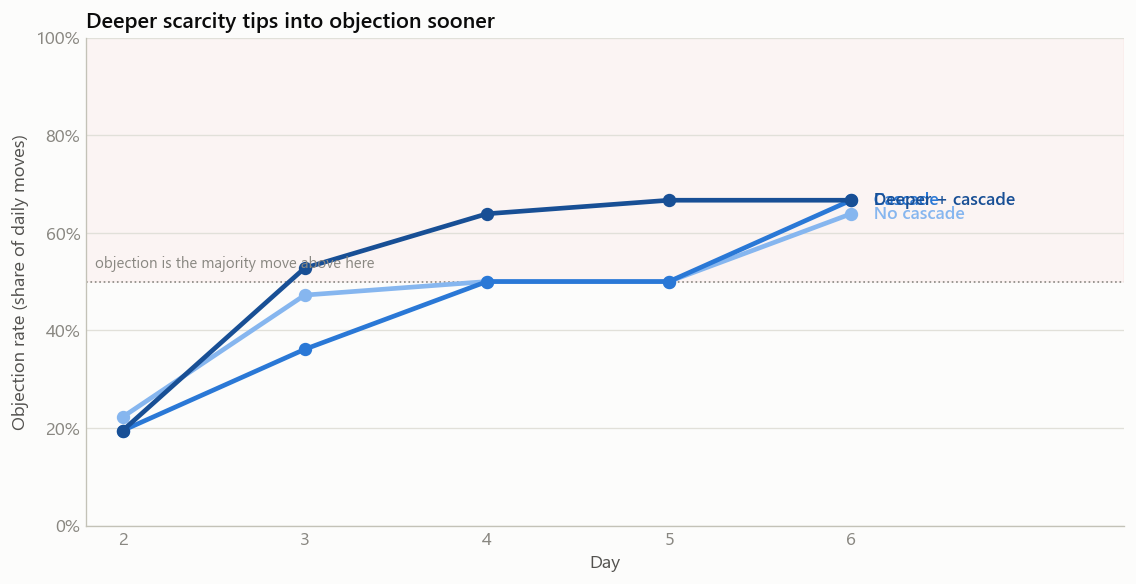

In [25]:
# === Chart 13c — objection rate per condition, day by day =====================
rate = (mvd.groupby(['condition', 'day'])['obj'].mean() * 100).unstack('condition')

fig, ax = plt.subplots(figsize=(9.6, 5))
ax.axhspan(50, 100, color=OBJ_C, alpha=0.04, zorder=0)   # "objection majority" band
for cond in COND_ORDER:
    y = rate[cond].reindex(MDAYS)
    ax.plot(MDAYS, y, color=COND_COLOR[cond], lw=2.8, marker='o', ms=7,
            zorder=3, solid_capstyle='round')
    ax.text(MDAYS[-1] + 0.1, y.iloc[-1], f' {COND_LABEL[cond]}',
            color=COND_COLOR[cond], va='center', fontsize=10.5, fontweight='semibold')

ax.axhline(50, color=MUTED, lw=1, ls=':', zorder=1)
ax.text(MDAYS[0] - 0.15, 52, 'objection is the majority move above here',
        color=MUTED, va='bottom', fontsize=9)
ax.set_xticks(MDAYS); ax.set_xlim(MDAYS[0] - 0.2, MDAYS[-1] + 1.5)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.set_ylabel('Objection rate (share of daily moves)'); ax.set_xlabel('Day')
ax.set_title('Deeper scarcity tips into objection sooner', loc='left')
clean(ax); plt.tight_layout(); plt.show()

In [26]:
# --- The figures, in plain numbers --------------------------------------------
print('OBJECTIONS vs COOPERATION per day (pooled over all 9 runs)\n')
print(per_day[['Cooperation', 'Objections', 'Total', 'Coop %', 'Obj %']]
      .round(1).to_string())

tot_coop, tot_obj = int(per_day.Cooperation.sum()), int(per_day.Objections.sum())
tot = tot_coop + tot_obj
print(f'\nOverall: {tot_coop} cooperative moves vs {tot_obj} objections '
      f'({tot} total) -> {tot_coop / tot:.0%} cooperative, {tot_obj / tot:.0%} objection.')
print(f'Day {MDAYS[0]} starts at {per_day.loc[MDAYS[0], "Obj %"]:.0f}% objection; '
      f'by day {MDAYS[-1]} it reaches {per_day.loc[MDAYS[-1], "Obj %"]:.0f}%.')

OBJECTIONS vs COOPERATION per day (pooled over all 9 runs)

     Cooperation  Objections  Total  Coop %  Obj %
day                                               
2             86          22    108    79.6   20.4
3             59          49    108    54.6   45.4
4             49          59    108    45.4   54.6
5             48          60    108    44.4   55.6
6             37          71    108    34.3   65.7

Overall: 279 cooperative moves vs 261 objections (540 total) -> 52% cooperative, 48% objection.
Day 2 starts at 20% objection; by day 6 it reaches 66%.
